In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        14093, # Botas kuko
                        18718, # Escudo kuko
                        # 19985, # Anillo de vuelo

                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 80,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {}
                },
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1
                    },  # Exo MP
                "distributed_points": {
                    9: 995,  # Vitality
                }
            },
        }

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
# Items[Items["name"].str.contains("vuelo")]

In [5]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2748
Total item sets: 148
Total pools:
   16 with sizes [69, 118, 71, 71, 62, 1, 1, 88, 69, 412, 326, 326, 326, 326, 326, 326]
Total combinations: 10^30.88


In [6]:
pools = []
for t,count in opt.pool_types:
    if not isinstance(t, list):
        t = [t]
    for _ in range(count):
        pool = [id for id in opt.items if opt.items[id]["type"]["superTypeId"] in t]
        pools.append(pool)

In [ ]:
opt.optimize()

In [ ]:
print("Best solution fitness:", opt.solution.get_fitness())
print("Best solution weapon damage:", opt.solution.get_final_weapon_damage())
print("Best solution elemental damage:", opt.solution.get_final_elemental_damage())
print("Is the solution viable?", opt.solution.viable)
print("Was the solution penalized?", opt.solution.penalized)

Best solution fitness: 1897.675
Best solution weapon damage: 1897.675
Best solution elemental damage: 1450.0
Is the solution viable? True
Was the solution penalized? False


In [ ]:
opt.solution.totals_summary(effect_descriptions)#.sort_values("value",ascending=False)

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,4710.0
10,sabiduría,395.0
12,PA,12.0
13,inteligencia,480.0
14,de resistencia al fuego,40.0
15,de resistencia a la tierra,35.0
16,% resistencia al aire,37.0
17,% resistencia al agua,43.0


In [ ]:
set_summary = opt.solution.set_summary()
set_summary

,type_id,type,description,level,set
694,13,Dofus,Dofus Púrpura,110,None
739,13,Dofus,Dofus Turquesa,160,None
7043,13,Dofus,Dofus de los hielos,180,None
7754,13,Dofus,Dofus Ocre,160,None
8993,2,Espada,Espada maldita del gran Desangrador Guerrero,200,None
12116,10,Sombrero,Corona de Golosotrón Real,195,None
13344,13,Dofus,Dolmanax,100,None
13759,13,Trofeo,Hércules mayor,150,None
14092,3,Anillo,Anillo de kukoloide,200,Set de kukoloide
14093,5,Bota,Botas de kukoloide,200,Set de kukoloide


In [ ]:
set_summary["set"].value_counts()

set
Set de kukoloide     3
Set de charlatán     2
Set de estrígido     1
Set de Corrupción    1
Name: count, dtype: int64

Text(0, 0.5, 'Best Fitness')

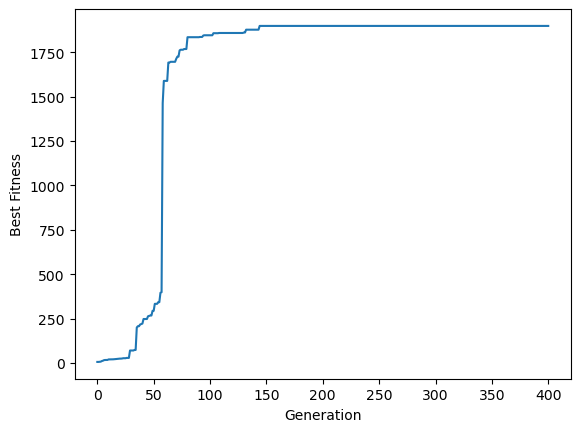

In [ ]:
import matplotlib.pyplot as plt
plt.plot(opt.ga_instance.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [ ]:
assert False

AssertionError: 

In [ ]:
# Current
chr = Chromosome([
                    8993, # Espada
                    13641, 13643, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    19985, # Vuelo
                    18670, # Escudo
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

1890.67

In [ ]:
Items[Items["name"].str.contains("kuko")]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)